In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

from pathlib import Path
from collections import Counter, defaultdict

from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:

# Main analysis choices
MIN_REPEATS_PER_HASH = 2
MIN_SHARED_NEURONS_PER_HASH = 100      # overlap threshold for wide-table candidate
MAX_HASHES_FOR_WIDE_TABLE = 40         # keep dimensionality manageable
RANDOM_STATE = 42

# Label order for reports
LAYER_ORDER = ["L2/3", "L4", "L5", "L6"]

# 1. Build the unified table with one best functional match per neuron
cleaner = mic.MicronsDataCleaner(datadir="../data", version=1718, download_policy="minimum")
units, segments = cleaner.process_nucleus_data(functional_data="best_only")

print("units shape:", units.shape)
print("segments shape:", segments.shape)
print("\nColumns:")
print(sorted(units.columns.tolist()))

# 2. Basic sanity checks on the full table
for col in ["classification_system", "cell_type", "layer", "brain_area", "tuning_type", "session", "scan_idx", "unit_id"]:
    if col in units.columns:
        print(f"\nValue counts for {col}:")
        print(units[col].value_counts(dropna=False).head(20))

# 3. Restrict to the population relevant for the project
#    excitatory + matched functional + V1
u = units.copy()

# adjust these only if the exact column names/categories differ in your table
if "classification_system" in u.columns:
    u = u[u["classification_system"] == "excitatory_neuron"]

if "tuning_type" in u.columns:
    u = u[u["tuning_type"] != "not_matched"]

if "brain_area" in u.columns:
    u = u[u["brain_area"] == "V1"]

print("\nFiltered population shape (excitatory, matched, V1):", u.shape)

# 4. Check candidate targets
for col in ["layer", "cell_type"]:
    if col in u.columns:
        print(f"\nFiltered value counts for {col}:")
        print(u[col].value_counts(dropna=False))

# 5. Check uniqueness of neurons
for col in ["pt_root_id", "nucleus_id"]:
    if col in u.columns:
        print(f"\nUnique {col}: {u[col].nunique()} / rows: {len(u)}")

# 6. Missingness on likely important columns
important_cols = [c for c in ["pt_root_id", "nucleus_id", "layer", "cell_type", "brain_area",
                              "tuning_type", "session", "scan_idx", "unit_id"] if c in u.columns]
print("\nMissing values in important columns:")
print(u[important_cols].isna().sum().sort_values(ascending=False))

Transform positions: 100%|██████████| 94014/94014 [00:00<00:00, 127161.27it/s]


units shape: (90434, 20)
segments shape: (5, 5)

Columns:
['brain_area', 'cc_abs', 'cell_type', 'classification_system', 'gDSI', 'gOSI', 'layer', 'nucleus_id', 'pref_dir', 'pref_ori', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'pt_root_id', 'scan_idx', 'session', 'strategy_axon', 'strategy_dendrite', 'tuning_type', 'unit_id']

Value counts for classification_system:
classification_system
excitatory_neuron    63822
nonneuron            18762
inhibitory_neuron     7850
Name: count, dtype: int64

Value counts for cell_type:
cell_type
23P          19658
4P           14729
6P-IT        11670
5P-IT         7909
astrocyte     7129
oligo         6909
6P-CT         6775
BC            3333
MC            2454
microglia     2413
5P-ET         2149
BPC           1499
OPC           1461
5P-NP          932
pericyte       850
NGC            564
Name: count, dtype: int64

Value counts for layer:
layer
L6      27447
L2/3    25153
L4      18770
L5      17576
L1       1487
NaN         1
Name: coun

In [3]:
import microns_datacleaner as mic
import pandas as pd
import numpy as np

# Keep only the layer target we decided to use
u_layer = u[u["layer"].isin(["L2/3", "L4", "L5", "L6"])].copy()
print("u_layer shape:", u_layer.shape)
print("\nLayer counts:")
print(u_layer["layer"].value_counts())

# Build session keys available in the matched V1 excitatory set
u_layer["session_key"] = (
    u_layer["session"].astype(int).astype(str) + "_" +
    u_layer["scan_idx"].astype(int).astype(str)
)

print("\nNumber of distinct session_key:", u_layer["session_key"].nunique())
print("Session_key counts:")
print(u_layer["session_key"].value_counts())

# Open the functional reader
fr = mic.MicronsFunctionalReader(datadir="../data")

# Optional: inspect structure once
print("\nFunctional file structure:")
fr.print_structure()

# For each session_key, inspect how many condition hashes exist
session_keys = sorted(u_layer["session_key"].unique())

session_hash_summary = []
for sk in session_keys:
    hashes_all = fr.get_hashes_by_session(sk, return_unique=False)
    hashes_unique = fr.get_hashes_by_session(sk, return_unique=True)
    session_hash_summary.append({
        "session_key": sk,
        "n_trials_listed": len(hashes_all),
        "n_unique_hashes": len(hashes_unique)
    })

session_hash_summary = pd.DataFrame(session_hash_summary).sort_values("session_key")
print("\nSession/hash summary:")
print(session_hash_summary)

# Pick one session key to inspect in more detail: the one with most neurons
top_session = u_layer["session_key"].value_counts().idxmax()
print("\nTop session_key:", top_session)

hashes_all = fr.get_hashes_by_session(top_session, return_unique=False)
hashes_unique = list(fr.get_hashes_by_session(top_session, return_unique=True))

print("\nFirst 20 hashes in top session:")
print(hashes_all[:20])

print("\nNumber of repeated presentations in top session:")
print("total hashes listed:", len(hashes_all))
print("unique hashes:", len(hashes_unique))

# Inspect one example hash
example_hash = hashes_all[0]
print("\nExample hash:", example_hash)

resp = fr.get_responses_by_hash(example_hash, brain_area="V1")
print("\nType of resp:", type(resp))
print("Number of trial entries for this hash:", len(resp))

if len(resp) > 0:
    print("\nKeys in first response entry:")
    print(resp[0].keys())
    print("Session:", resp[0]["session"])
    print("Trial idx:", resp[0]["trial_idx"])
    print("Responses type:", type(resp[0]["responses"]))
    try:
        print("Responses shape:", np.array(resp[0]["responses"]).shape)
    except:
        print("Could not infer response shape directly")

# Inspect one trial directly
trial0 = fr.get_trial(top_session, 0, brain_area="V1")
print("\nTrial 0 keys:")
print(trial0.keys())

for k, v in trial0.items():
    if hasattr(v, "shape"):
        print(k, "shape:", v.shape)
    else:
        print(k, "type:", type(v))

u_layer shape: (8895, 20)

Layer counts:
layer
L2/3    4247
L4      2670
L5      1615
L6       363
Name: count, dtype: int64

Number of distinct session_key: 13
Session_key counts:
session_key
6_4    916
6_7    874
9_3    818
8_5    780
6_2    774
4_7    715
5_7    701
6_6    697
5_6    686
9_4    680
7_3    552
9_6    428
7_5    274
Name: count, dtype: int64

Functional file structure:

Structure of: /Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/katia/1.APPROACH/../data/functional/microns_functional.h5
📂 BRAIN_AREAS/ 
    📂 AL/ 
        🔗 4_7                -> /sessions/4_7
        🔗 5_6                -> /sessions/5_6
        🔗 5_7                -> /sessions/5_7
        🔗 6_2                -> /sessions/6_2
        🔗 6_4                -> /sessions/6_4
        ... and 9 more items
    📂 LM/ 
        🔗 4_7                -> /sessions/4_7
        🔗 5_6                -> /sessions/5_6
        🔗 5_7                -> /sessions/5_7
        🔗 6_2                -> /sessions/6_2

In [9]:
# ------------------------------------------------------------
# BUILD PRIMARY NEURON TABLE
# one row per biological neuron for the main analysis
# ------------------------------------------------------------
u0 = u_layer.copy()

u0["session_key"] = (
    u0["session"].astype(int).astype(str) + "_" +
    u0["scan_idx"].astype(int).astype(str)
)

# Restrict to the four layers of interest
u0 = u0[u0["layer"].isin(LAYER_ORDER)].copy()

# Prefer an explicit best-scan flag if present
best_flag_candidates = [
    c for c in u0.columns
    if c.lower() in {"best_scan", "best_only", "is_best", "best_match"}
]

if len(best_flag_candidates) > 0:
    best_col = best_flag_candidates[0]
    u_best = u0[u0[best_col].astype(bool)].copy()
    print(f"Using explicit best-recording flag: {best_col}")
else:
    # Fallback: keep one row per pt_root_id
    # If you later want a repeated-measures notebook, do it separately.
    u_best = (
        u0.sort_values(["pt_root_id", "session", "scan_idx"])
          .drop_duplicates(subset=["pt_root_id"], keep="first")
          .copy()
    )
    print("No explicit best-recording flag found.")
    print("Fallback used: first occurrence per pt_root_id.")

print("\nPrimary neuron table shape:", u_best.shape)
print("\nLayer counts:")
print(u_best["layer"].value_counts().reindex(LAYER_ORDER))
print("\nSession counts:")
print(u_best["session_key"].value_counts().sort_index())
print("\nNumber of unique neurons:", u_best["pt_root_id"].nunique())
u0

No explicit best-recording flag found.
Fallback used: first occurrence per pt_root_id.

Primary neuron table shape: (8895, 21)

Layer counts:
layer
L2/3    4247
L4      2670
L5      1615
L6       363
Name: count, dtype: int64

Session counts:
session_key
4_7    715
5_6    686
5_7    701
6_2    774
6_4    916
6_6    697
6_7    874
7_3    552
7_5    274
8_5    780
9_3    818
9_4    680
9_6    428
Name: count, dtype: int64

Number of unique neurons: 8895


,nucleus_id,pt_root_id,pt_position_x,pt_position_y,pt_position_z,classification_system,cell_type,brain_area,strategy_axon,strategy_dendrite,...,scan_idx,unit_id,pref_ori,pref_dir,gOSI,gDSI,cc_abs,tuning_type,layer,session_key
16,189115,864691135738006641,501.233729,104.152149,960.08,excitatory_neuron,23P,V1,none,none,...,2.0,2184.0,33.797480,213.797490,0.359622,0.023755,0.373394,matched,L2/3,6_2
20,153275,864691135463256477,476.232006,135.114928,804.24,excitatory_neuron,23P,V1,none,none,...,2.0,1890.0,101.958984,101.958984,0.062396,0.056385,0.563241,matched,L2/3,6_2
21,153085,864691135748985641,475.434732,106.777609,743.60,excitatory_neuron,23P,V1,none,none,...,7.0,1525.0,114.008705,294.008700,0.125745,0.069892,0.344436,matched,L2/3,6_7
34,363874,864691135699950114,851.072250,316.056947,942.16,excitatory_neuron,4P,V1,none,none,...,3.0,4674.0,49.381397,49.381397,0.090021,0.130261,0.434939,matched,L4,7_3
36,362609,864691136126239014,855.283500,257.641694,667.00,excitatory_neuron,4P,V1,none,none,...,7.0,4939.0,29.099228,209.099230,0.175061,0.045681,0.345238,matched,L4,5_7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90396,231586,864691135395987701,536.576139,444.784653,640.92,excitatory_neuron,5P-ET,V1,none,none,...,5.0,10433.0,137.930270,317.930270,0.127548,0.082682,0.605237,matched,L5,8_5
90410,303557,864691135213195392,659.127328,465.657119,1043.04,excitatory_neuron,5P-ET,V1,none,none,...,3.0,9069.0,90.927100,270.927100,0.278685,0.045615,0.403380,matched,L5,7_3
90417,369945,864691135375228745,798.635712,449.851932,853.00,excitatory_neuron,5P-ET,V1,none,none,...,3.0,8708.0,96.252750,276.252750,0.220711,0.052468,0.491141,matched,L5,7_3
90418,302754,864691135114540953,652.650672,483.143181,801.92,excitatory_neuron,5P-ET,V1,none,none,...,7.0,8085.0,91.149414,271.149400,0.332690,0.087670,0.866769,matched,L5,4_7


Neurons with >1 matched recording block: 0
Max number of matched blocks for one neuron: 1


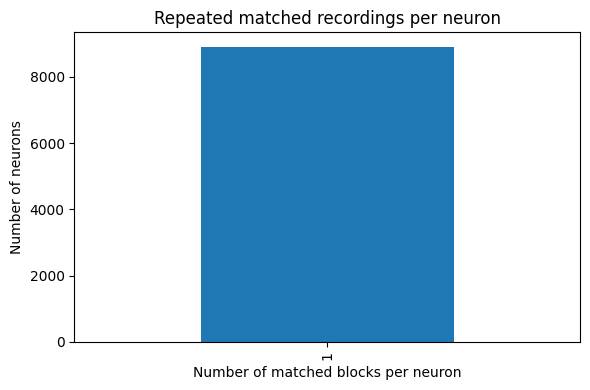

In [8]:
# ------------------------------------------------------------
# DIAGNOSTIC: repeated recordings per neuron in original table
# ------------------------------------------------------------
dup_counts = u0.groupby("pt_root_id").size()
print("Neurons with >1 matched recording block:", (dup_counts > 1).sum())
print("Max number of matched blocks for one neuron:", dup_counts.max())

plt.figure(figsize=(6, 4))
dup_counts.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of matched blocks per neuron")
plt.ylabel("Number of neurons")
plt.title("Repeated matched recordings per neuron")
plt.tight_layout()
plt.show()

In [10]:
# ------------------------------------------------------------
# MAP each neuron to a V1 functional row in its session_key
# ------------------------------------------------------------
mapped_blocks = []
session_map_report = []

for session_key in sorted(u_best["session_key"].unique()):
    u_sess = u_best[u_best["session_key"] == session_key].copy()
    n_start = len(u_sess)

    all_unit_ids = fr.f[f"sessions/{session_key}/meta/unit_ids"][:]
    v1_idx = fr.f[f"sessions/{session_key}/meta/area_indices/V1"][:]
    v1_unit_ids = all_unit_ids[v1_idx]

    unitid_to_row_v1 = {int(uid): i for i, uid in enumerate(v1_unit_ids)}

    u_sess["func_row"] = u_sess["unit_id"].astype(int).map(unitid_to_row_v1)
    u_sess = u_sess[u_sess["func_row"].notna()].copy()
    u_sess["func_row"] = u_sess["func_row"].astype(int)

    mapped_blocks.append(u_sess)

    session_map_report.append({
        "session_key": session_key,
        "n_units_start": n_start,
        "n_units_found_in_V1": len(u_sess)
    })

u_best_func = pd.concat(mapped_blocks, ignore_index=True)
session_map_report_df = pd.DataFrame(session_map_report).sort_values("session_key")

print("Mapped neuron table shape:", u_best_func.shape)
print("\nMapping report:")
print(session_map_report_df)

Mapped neuron table shape: (8832, 22)

Mapping report:
   session_key  n_units_start  n_units_found_in_V1
0          4_7            715                  709
1          5_6            686                  682
2          5_7            701                  698
3          6_2            774                  764
4          6_4            916                  905
5          6_6            697                  692
6          6_7            874                  868
7          7_3            552                  549
8          7_5            274                  269
9          8_5            780                  776
10         9_3            818                  813
11         9_4            680                  680
12         9_6            428                  427


Hash audit shape: (1768, 4)
Trace-length audit shape: (1768, 6)

Top hashes by neuron overlap:
                    hash  n_neuron_observations
0   5zQTb77qI+ig8rigx1XU                   8832
1   mbeT2YEuzrol94GMBsSP                   8832
2   F5KOXJGuqZljKK9USGu/                   8832
3   NM2SnnQwIoj8iKOMP6xA                   8832
4   0ir9/br3yxbe2BBf65zF                   8832
5   shDuGRZylVmZLCBFIVeP                   8832
6   gpu0WyfdPMgXV/xhy6ZP                   8832
7   SuNRz+E/BsGGxVlNWLt9                   8832
8   AXD+rrWG8VbV+xLvzwfb                   8832
9   8IyLxfa6UikBgn/lOdpD                   8832
10  s8DvZS/fghphUcTsLOzM                   8832
11  cK20wOm48y1gpxBcZuzN                   8832
12  18PTv0aCUhaUeL2r9kDd                   8832
13  MaN8zZQItdhsFNBq5/yl                   8832
14  QmynNYnz4Q0hMBpTZ/xv                   8832
15  YxZMp94AewnnwYmjI/0v                   8832
16  YWz8BdF7JHpb7SyGU3LO                   8832
17  iXM+aZY10zP+t3wPmZOW                 

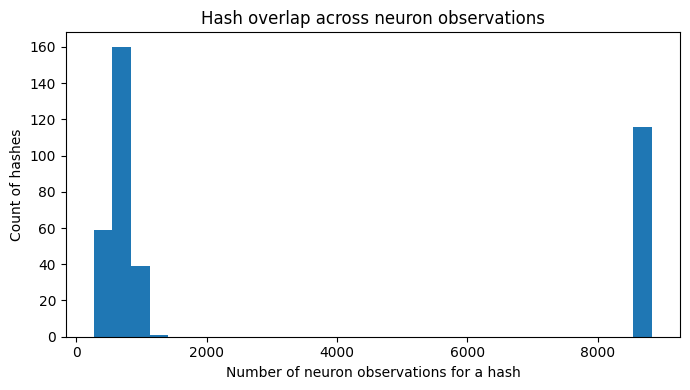


Trace-length consistency examples:
   session_key                  hash  n_trials unique_trace_lengths  min_len  \
0          4_7  5zQTb77qI+ig8rigx1XU        10                (75,)       75   
1          4_7  Oup5uAZxF2G7zEJkT+ui        10                (75,)       75   
2          4_7  7UETOWO5Z8aWuHDBJ2GG        10                (75,)       75   
3          4_7  ecUQJtcERZJGdqza1k7h        10                (75,)       75   
4          4_7  GjCMo2GkJp6y5vricadg        10                (75,)       75   
5          4_7  KXdTNAGMo1gCWz2Ge8zr        10                (75,)       75   
6          4_7  yAH9HaWI/xVA35yTf/aY         2               (113,)      113   
7          4_7  FwG4V5nAZdXPlcAEu/X9         2               (113,)      113   
8          4_7  Uz0eRwz/MjTDK3dkTUCD         2               (113,)      113   
9          4_7  ZJvulWBItHtLlDVkIntm         2               (113,)      113   
10         4_7  Td0j9+lkU+ZRdgIUDMl9         2               (113,)      113   
11  

In [11]:
# ------------------------------------------------------------
# AUDIT:
# 1) which repeated hashes exist,
# 2) how many neurons have each hash,
# 3) whether trace length is stable for a hash
# ------------------------------------------------------------
hash_rows = []
trace_len_rows = []

for session_key in sorted(u_best_func["session_key"].unique()):
    u_sess = u_best_func[u_best_func["session_key"] == session_key].copy()
    hashes_all = fr.get_hashes_by_session(session_key, return_unique=False)
    hash_counts = pd.Series(hashes_all).value_counts()
    usable_hashes = hash_counts[hash_counts >= MIN_REPEATS_PER_HASH].index.tolist()

    for h in usable_hashes:
        hash_rows.append({
            "session_key": session_key,
            "hash": h,
            "n_repeats_in_session": int(hash_counts[h]),
            "n_neurons_in_session": len(u_sess)
        })

        resp_list = fr.get_responses_by_hash(h, brain_area="V1")
        resp_list = [r for r in resp_list if r["session"] == session_key]
        if len(resp_list) > 0:
            lens = [r["responses"].shape[-1] for r in resp_list]
            trace_len_rows.append({
                "session_key": session_key,
                "hash": h,
                "n_trials": len(resp_list),
                "unique_trace_lengths": tuple(sorted(set(lens))),
                "min_len": int(np.min(lens)),
                "max_len": int(np.max(lens))
            })

hash_audit = pd.DataFrame(hash_rows)
trace_len_audit = pd.DataFrame(trace_len_rows)

print("Hash audit shape:", hash_audit.shape)
print("Trace-length audit shape:", trace_len_audit.shape)

# Global overlap across neurons after best-only selection:
# count in how many neurons each hash will appear once we build neuron-hash rows
hash_neuron_counter = Counter()

for session_key in sorted(u_best_func["session_key"].unique()):
    u_sess = u_best_func[u_best_func["session_key"] == session_key].copy()
    hashes_all = fr.get_hashes_by_session(session_key, return_unique=False)
    hash_counts = pd.Series(hashes_all).value_counts()
    usable_hashes = hash_counts[hash_counts >= MIN_REPEATS_PER_HASH].index.tolist()

    for h in usable_hashes:
        # if a hash is in this session, all mapped neurons in this block see it
        hash_neuron_counter[h] += len(u_sess)

hash_overlap_df = (
    pd.DataFrame({
        "hash": list(hash_neuron_counter.keys()),
        "n_neuron_observations": list(hash_neuron_counter.values())
    })
    .sort_values("n_neuron_observations", ascending=False)
    .reset_index(drop=True)
)

print("\nTop hashes by neuron overlap:")
print(hash_overlap_df.head(20))

plt.figure(figsize=(7, 4))
plt.hist(hash_overlap_df["n_neuron_observations"], bins=30)
plt.xlabel("Number of neuron observations for a hash")
plt.ylabel("Count of hashes")
plt.title("Hash overlap across neuron observations")
plt.tight_layout()
plt.show()

print("\nTrace-length consistency examples:")
print(trace_len_audit.head(20))

In [ ]:
# ------------------------------------------------------------
# BUILD LONG TABLE: one row per neuron x hash
# repeated trials of same hash are averaged pointwise first
# ------------------------------------------------------------
long_rows = []
long_report = []

for session_key in sorted(u_best_func["session_key"].unique()):
    print(f"\n===== Building neuron x hash table for session {session_key} =====")
    u_sess = u_best_func[u_best_func["session_key"] == session_key].copy()
    n_start = len(u_sess)

    hashes_all = fr.get_hashes_by_session(session_key, return_unique=False)
    hash_counts = pd.Series(hashes_all).value_counts()
    usable_hashes = hash_counts[hash_counts >= MIN_REPEATS_PER_HASH].index.tolist()

    n_rows_before = len(long_rows)

    for h in usable_hashes:
        resp_list = fr.get_responses_by_hash(h, brain_area="V1")
        resp_list = [r for r in resp_list if r["session"] == session_key]

        if len(resp_list) < MIN_REPEATS_PER_HASH:
            continue

        X = np.stack([r["responses"] for r in resp_list], axis=0)  # trials x neurons x T
        X = X[:, u_sess["func_row"].values, :]                     # trials x selected_neurons x T

        T = X.shape[-1]
        t_rel = np.linspace(0.0, 1.0, T) if T > 1 else np.array([0.0])

        Xmean = X.mean(axis=0)  # neurons x T

        peak = Xmean.max(axis=1)
        trough = Xmean.min(axis=1)
        mean_resp = Xmean.mean(axis=1)
        std_resp = Xmean.std(axis=1)
        argpeak_rel = Xmean.argmax(axis=1) / (T - 1) if T > 1 else np.zeros(Xmean.shape[0])

        Xshift = Xmean - Xmean.min(axis=1, keepdims=True)
        denom = Xshift.sum(axis=1)
        com_rel = np.where(denom > 0, (Xshift * t_rel).sum(axis=1) / denom, np.nan)

        # Reliability = average pairwise corr across repeated trials for each neuron
        reliability = []
        for i in range(X.shape[1]):
            Xi = X[:, i, :]
            C = np.corrcoef(Xi)
            iu = np.triu_indices_from(C, k=1)
            reliability.append(np.nanmean(C[iu]))
        reliability = np.array(reliability)

        dfh = pd.DataFrame({
            "pt_root_id": u_sess["pt_root_id"].values,
            "layer": u_sess["layer"].values,
            "session_key": session_key,
            "hash": h,
            "trace_len": T,
            "n_repeats": X.shape[0],
            "peak": peak,
            "trough": trough,
            "mean_resp": mean_resp,
            "std_resp": std_resp,
            "argpeak_rel": argpeak_rel,
            "com_rel": com_rel,
            "reliability": reliability
        })
        long_rows.append(dfh)

    n_rows_after = len(long_rows)
    long_report.append({
        "session_key": session_key,
        "n_neurons": n_start,
        "n_hashes_used": len(usable_hashes),
        "n_rows_added": sum(len(x) for x in long_rows[n_rows_before:])
    })

feat_neuron_hash = pd.concat(long_rows, ignore_index=True)
long_report_df = pd.DataFrame(long_report).sort_values("session_key")

print("\nFinal neuron x hash table shape:", feat_neuron_hash.shape)
print("\nColumns:", list(feat_neuron_hash.columns))
print("\nMissing values:")
print(feat_neuron_hash.isna().sum().sort_values(ascending=False).head(20))
print("\nPer-session report:")
print(long_report_df)

feat_neuron_hash.to_pickle("dataset/feat_neuron_hash.pkl")
print("\nSaved:", "feat_neuron_hash.pkl")


===== Building neuron x hash table for session 4_7 =====

===== Building neuron x hash table for session 5_6 =====

===== Building neuron x hash table for session 5_7 =====

===== Building neuron x hash table for session 6_2 =====

===== Building neuron x hash table for session 6_4 =====

===== Building neuron x hash table for session 6_6 =====

===== Building neuron x hash table for session 6_7 =====

===== Building neuron x hash table for session 7_3 =====

===== Building neuron x hash table for session 7_5 =====

===== Building neuron x hash table for session 8_5 =====

===== Building neuron x hash table for session 9_3 =====

===== Building neuron x hash table for session 9_4 =====

===== Building neuron x hash table for session 9_6 =====

Final neuron x hash table shape: (1201152, 13)

Columns: ['pt_root_id', 'layer', 'session_key', 'hash', 'trace_len', 'n_repeats', 'peak', 'trough', 'mean_resp', 'std_resp', 'argpeak_rel', 'com_rel', 'reliability']

Missing values:
pt_root_id    

In [ ]:
# ------------------------------------------------------------
# OPTIONAL: attach stimulus class metadata if available
# ------------------------------------------------------------
stim_desc_path = "dataset/stim_hash_descriptors.pkl"

if stim_desc_path.exists():
    stim_desc = pd.read_pickle(stim_desc_path).copy()
    keep_cols = ["hash", "stim_type"]
    stim_desc = stim_desc[keep_cols].drop_duplicates()

    feat_neuron_hash = feat_neuron_hash.merge(stim_desc, on="hash", how="left")
    feat_neuron_hash["stim_type"] = feat_neuron_hash["stim_type"].str.lower()

    print("Stimulus descriptors attached.")
    print(feat_neuron_hash["stim_type"].value_counts(dropna=False))
else:
    feat_neuron_hash["stim_type"] = np.nan
    print("No stimulus descriptor file found. Continuing without stim_type.")

Eligible hashes for wide table: 40
Top eligible hashes: ['5zQTb77qI+ig8rigx1XU', 'mbeT2YEuzrol94GMBsSP', 'F5KOXJGuqZljKK9USGu/', 'NM2SnnQwIoj8iKOMP6xA', '0ir9/br3yxbe2BBf65zF', 'shDuGRZylVmZLCBFIVeP', 'gpu0WyfdPMgXV/xhy6ZP', 'SuNRz+E/BsGGxVlNWLt9', 'AXD+rrWG8VbV+xLvzwfb', '8IyLxfa6UikBgn/lOdpD']
Wide table shape: (8832, 283)

Top columns by missingness:
peak__5zQTb77qI+ig8rigx1XU           0.0
mean_resp__8PA1UPAZQPiLL4qyfbe0      0.0
trough__Qtx9ZilPEN9mdem3G1lL         0.0
peak__Qtx9ZilPEN9mdem3G1lL           0.0
reliability__8PA1UPAZQPiLL4qyfbe0    0.0
com_rel__8PA1UPAZQPiLL4qyfbe0        0.0
argpeak_rel__8PA1UPAZQPiLL4qyfbe0    0.0
std_resp__8PA1UPAZQPiLL4qyfbe0       0.0
trough__8PA1UPAZQPiLL4qyfbe0         0.0
std_resp__Qtx9ZilPEN9mdem3G1lL       0.0
peak__8PA1UPAZQPiLL4qyfbe0           0.0
reliability__yCXacouyIMBJMNQBQeSe    0.0
com_rel__yCXacouyIMBJMNQBQeSe        0.0
argpeak_rel__yCXacouyIMBJMNQBQeSe    0.0
std_resp__yCXacouyIMBJMNQBQeSe       0.0
mean_resp__yCXacouyIMBJMNQBQe

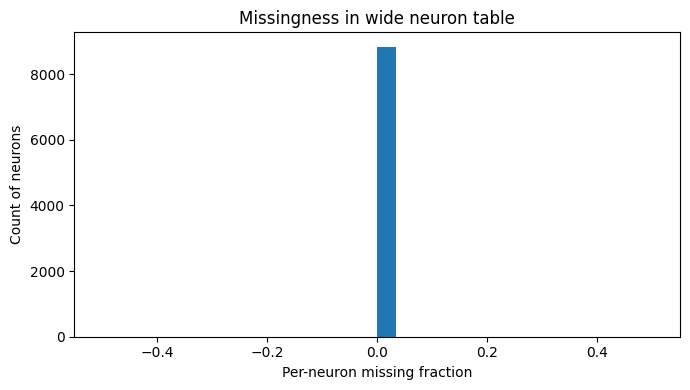


Saved: feat_wide_hash_conditioned.pkl


In [ ]:
# ------------------------------------------------------------
# WIDE TABLE CANDIDATE:
# one row per neuron, one block of columns per shared hash
# ------------------------------------------------------------
hash_counts_wide = feat_neuron_hash["hash"].value_counts()
eligible_hashes = hash_counts_wide[hash_counts_wide >= MIN_SHARED_NEURONS_PER_HASH].index.tolist()

# Keep top hashes by overlap, capped for dimensional sanity
eligible_hashes = eligible_hashes[:MAX_HASHES_FOR_WIDE_TABLE]

print("Eligible hashes for wide table:", len(eligible_hashes))
print("Top eligible hashes:", eligible_hashes[:10])

wide_base = u_best_func[["pt_root_id", "layer", "session_key"]].drop_duplicates().copy()

wide_blocks = []

base_feature_cols = ["peak", "trough", "mean_resp", "std_resp", "argpeak_rel", "com_rel", "reliability"]

for h in eligible_hashes:
    sub = feat_neuron_hash.loc[feat_neuron_hash["hash"] == h,
                               ["pt_root_id"] + base_feature_cols].copy()
    sub = sub.rename(columns={c: f"{c}__{h}" for c in base_feature_cols})
    wide_blocks.append(sub)

feat_wide = wide_base.copy()
for sub in wide_blocks:
    feat_wide = feat_wide.merge(sub, on="pt_root_id", how="left")

print("Wide table shape:", feat_wide.shape)

wide_feature_cols = [c for c in feat_wide.columns if c not in ["pt_root_id", "layer", "session_key"]]
missing_rate = feat_wide[wide_feature_cols].isna().mean().sort_values(ascending=False)

print("\nTop columns by missingness:")
print(missing_rate.head(20))

plt.figure(figsize=(7, 4))
plt.hist(feat_wide[wide_feature_cols].isna().mean(axis=1), bins=30)
plt.xlabel("Per-neuron missing fraction")
plt.ylabel("Count of neurons")
plt.title("Missingness in wide neuron table")
plt.tight_layout()
plt.show()

feat_wide.to_pickle("dataset/feat_wide_hash_conditioned.pkl")
print("\nSaved:", "feat_wide_hash_conditioned.pkl")

In [16]:
# ------------------------------------------------------------
# DECISION DIAGNOSTIC for wide table
# ------------------------------------------------------------
row_missing_fraction = feat_wide[wide_feature_cols].isna().mean(axis=1)

print("Median per-neuron missing fraction:", row_missing_fraction.median())
print("90th percentile missing fraction:", row_missing_fraction.quantile(0.90))
print("Neurons with <= 20% missing:", (row_missing_fraction <= 0.20).mean())
print("Neurons with <= 40% missing:", (row_missing_fraction <= 0.40).mean())

Median per-neuron missing fraction: 0.0
90th percentile missing fraction: 0.0
Neurons with <= 20% missing: 1.0
Neurons with <= 40% missing: 1.0


In [18]:
# ------------------------------------------------------------
# LONG TABLE CLASSIFICATION
# ------------------------------------------------------------
long_df = feat_neuron_hash.copy()

long_feature_cols = [
    "peak", "trough", "mean_resp", "std_resp",
    "argpeak_rel", "com_rel", "reliability", "n_repeats", "trace_len"
]

X_long = long_df[long_feature_cols].copy()
y_long = long_df["layer"].copy()
groups_neuron = long_df["pt_root_id"].copy()
groups_session = long_df["session_key"].copy()

base_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

param_grid = {"clf__C": [0.01, 0.1, 1.0, 10.0]}


def run_grouped_nested_cv(X, y, outer_groups, inner_groups, title=""):
    outer_cv = GroupKFold(n_splits=min(5, outer_groups.nunique()))
    y_true_all, y_pred_all = [], []
    chosen_params = []
    fold_rows = []

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y, groups=outer_groups), start=1):
        X_train, X_test = X.iloc[tr_idx], X.iloc[te_idx]
        y_train, y_test = y.iloc[tr_idx], y.iloc[te_idx]
        inner_grp = inner_groups.iloc[tr_idx]

        n_inner_splits = min(4, inner_grp.nunique())
        if n_inner_splits < 2:
            raise ValueError("Not enough inner groups for nested CV.")

        inner_cv = GroupKFold(n_splits=n_inner_splits)

        search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            scoring="balanced_accuracy",
            cv=inner_cv,
            n_jobs=-1
        )
        search.fit(X_train, y_train, clf__sample_weight=None, groups=inner_grp)

        y_hat = search.best_estimator_.predict(X_test)

        y_true_all.extend(y_test.tolist())
        y_pred_all.extend(y_hat.tolist())
        chosen_params.append(search.best_params_)

        fold_rows.append({
            "fold": fold,
            "n_test": len(te_idx),
            "accuracy": accuracy_score(y_test, y_hat),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_hat),
            "macro_f1": f1_score(y_test, y_hat, average="macro"),
            "best_params": search.best_params_
        })

        print(f"Fold {fold}: best_params={search.best_params_}")

    print("\nAccuracy:", accuracy_score(y_true_all, y_pred_all))
    print("Balanced accuracy:", balanced_accuracy_score(y_true_all, y_pred_all))
    print("Macro F1:", f1_score(y_true_all, y_pred_all, average="macro"))

    print("\nClassification report:")
    print(classification_report(y_true_all, y_pred_all, labels=LAYER_ORDER, zero_division=0))

    cm = confusion_matrix(y_true_all, y_pred_all, labels=LAYER_ORDER)
    print("\nConfusion matrix:")
    print(pd.DataFrame(cm, index=LAYER_ORDER, columns=LAYER_ORDER))

    fold_df = pd.DataFrame(fold_rows)
    params_df = pd.Series([str(x) for x in chosen_params]).value_counts()

    return {
        "y_true": y_true_all,
        "y_pred": y_pred_all,
        "fold_df": fold_df,
        "best_params_counts": params_df,
        "accuracy": accuracy_score(y_true_all, y_pred_all),
        "balanced_accuracy": balanced_accuracy_score(y_true_all, y_pred_all),
        "macro_f1": f1_score(y_true_all, y_pred_all, average="macro")
    }


# A) grouped by neuron: no same-neuron leakage
res_long_by_neuron = run_grouped_nested_cv(
    X=X_long,
    y=y_long,
    outer_groups=groups_neuron,
    inner_groups=groups_neuron,
    title="LONG TABLE: grouped nested CV by neuron"
)

# B) grouped by session: stronger domain-shift test
res_long_by_session = run_grouped_nested_cv(
    X=X_long,
    y=y_long,
    outer_groups=groups_session,
    inner_groups=groups_session,
    title="LONG TABLE: grouped nested CV by session"
)


LONG TABLE: grouped nested CV by neuron
Fold 1: best_params={'clf__C': 10.0}
Fold 2: best_params={'clf__C': 10.0}
Fold 3: best_params={'clf__C': 0.1}
Fold 4: best_params={'clf__C': 1.0}
Fold 5: best_params={'clf__C': 10.0}

Accuracy: 0.26834239130434784
Balanced accuracy: 0.37417828012387877
Macro F1: 0.23958248625792206

Classification report:
              precision    recall  f1-score   support

        L2/3       0.56      0.32      0.41    576640
          L4       0.35      0.10      0.15    360536
          L5       0.23      0.30      0.26    215832
          L6       0.08      0.78      0.14     48144

    accuracy                           0.27   1201152
   macro avg       0.30      0.37      0.24   1201152
weighted avg       0.42      0.27      0.29   1201152


Confusion matrix:
        L2/3     L4      L5      L6
L2/3  185775  48516  124026  218323
L4    111333  34777   84631  129795
L5     34505  15406   64181  101740
L6      2647    681    7229   37587

LONG TABLE: group

In [19]:
# ------------------------------------------------------------
# WIDE TABLE CLASSIFICATION
# ------------------------------------------------------------
wide_df = feat_wide.copy()

X_wide = wide_df[wide_feature_cols].copy()
y_wide = wide_df["layer"].copy()
groups_wide_session = wide_df["session_key"].copy()

outer_cv = GroupKFold(n_splits=min(5, groups_wide_session.nunique()))

y_true_wide, y_pred_wide = [], []
chosen_params_wide = []
fold_rows_wide = []

print("\n" + "=" * 70)
print("WIDE TABLE: grouped nested CV by session")
print("=" * 70)

for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_wide, y_wide, groups=groups_wide_session), start=1):
    X_train, X_test = X_wide.iloc[tr_idx], X_wide.iloc[te_idx]
    y_train, y_test = y_wide.iloc[tr_idx], y_wide.iloc[te_idx]
    inner_grp = groups_wide_session.iloc[tr_idx]

    n_inner_splits = min(4, inner_grp.nunique())
    if n_inner_splits < 2:
        raise ValueError("Not enough session groups for inner CV.")

    inner_cv = GroupKFold(n_splits=n_inner_splits)

    search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=inner_cv,
        n_jobs=-1
    )
    search.fit(X_train, y_train, groups=inner_grp)

    y_hat = search.best_estimator_.predict(X_test)

    y_true_wide.extend(y_test.tolist())
    y_pred_wide.extend(y_hat.tolist())
    chosen_params_wide.append(search.best_params_)

    fold_rows_wide.append({
        "fold": fold,
        "n_test": len(te_idx),
        "accuracy": accuracy_score(y_test, y_hat),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_hat),
        "macro_f1": f1_score(y_test, y_hat, average="macro"),
        "best_params": search.best_params_
    })

    print(f"Fold {fold}: best_params={search.best_params_}")

print("\nAccuracy:", accuracy_score(y_true_wide, y_pred_wide))
print("Balanced accuracy:", balanced_accuracy_score(y_true_wide, y_pred_wide))
print("Macro F1:", f1_score(y_true_wide, y_pred_wide, average="macro"))

print("\nClassification report:")
print(classification_report(y_true_wide, y_pred_wide, labels=LAYER_ORDER, zero_division=0))

cm_wide = confusion_matrix(y_true_wide, y_pred_wide, labels=LAYER_ORDER)
print("\nConfusion matrix:")
print(pd.DataFrame(cm_wide, index=LAYER_ORDER, columns=LAYER_ORDER))

res_wide = {
    "accuracy": accuracy_score(y_true_wide, y_pred_wide),
    "balanced_accuracy": balanced_accuracy_score(y_true_wide, y_pred_wide),
    "macro_f1": f1_score(y_true_wide, y_pred_wide, average="macro"),
    "fold_df": pd.DataFrame(fold_rows_wide),
    "best_params_counts": pd.Series([str(x) for x in chosen_params_wide]).value_counts()
}


WIDE TABLE: grouped nested CV by session
Fold 1: best_params={'clf__C': 0.01}
Fold 2: best_params={'clf__C': 0.01}
Fold 3: best_params={'clf__C': 0.01}
Fold 4: best_params={'clf__C': 0.01}
Fold 5: best_params={'clf__C': 0.01}

Accuracy: 0.4129302536231884
Balanced accuracy: 0.4735403771299496
Macro F1: 0.39480682222955776

Classification report:
              precision    recall  f1-score   support

        L2/3       0.57      0.43      0.50      4240
          L4       0.33      0.30      0.32      2651
          L5       0.34      0.48      0.40      1587
          L6       0.26      0.68      0.37       354

    accuracy                           0.41      8832
   macro avg       0.37      0.47      0.39      8832
weighted avg       0.45      0.41      0.42      8832


Confusion matrix:
      L2/3    L4   L5   L6
L2/3  1844  1271  777  348
L4    1068   805  638  140
L5     272   351  758  206
L6      23    15   76  240


In [20]:
# ------------------------------------------------------------
# COMPARISON
# ------------------------------------------------------------
comparison = pd.DataFrame([
    {
        "protocol": "long_table_grouped_by_neuron",
        "accuracy": res_long_by_neuron["accuracy"],
        "balanced_accuracy": res_long_by_neuron["balanced_accuracy"],
        "macro_f1": res_long_by_neuron["macro_f1"]
    },
    {
        "protocol": "long_table_grouped_by_session",
        "accuracy": res_long_by_session["accuracy"],
        "balanced_accuracy": res_long_by_session["balanced_accuracy"],
        "macro_f1": res_long_by_session["macro_f1"]
    },
    {
        "protocol": "wide_table_grouped_by_session",
        "accuracy": res_wide["accuracy"],
        "balanced_accuracy": res_wide["balanced_accuracy"],
        "macro_f1": res_wide["macro_f1"]
    }
])

print(comparison)
comparison.to_pickle("new_notebook_comparison.pkl")
print("\nSaved:", "new_notebook_comparison.pkl")

                        protocol  accuracy  balanced_accuracy  macro_f1
0   long_table_grouped_by_neuron  0.268342           0.374178  0.239582
1  long_table_grouped_by_session  0.259908           0.370304  0.236961
2  wide_table_grouped_by_session  0.412930           0.473540  0.394807

Saved: new_notebook_comparison.pkl
